## Validation against ADCP data

Contains comparision of model output to ADCP data by calculating metrics and plotting velocity profiles.

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import helpers
from modules import metrics
from modules import read_files as read
from modules import ADCP as custom

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

### Configuration

In [2]:
# period, skip first day
start_date = '2023-01-14'
end_date = '2023-01-18T00'

# model output
dir_model_output = '../../data/model_output'
folder_name = 'L2'
base_name = 'layer' 

# ADCP data
dir_ADCP_upper = "../../data/ADCP/ADCP_upper_08.csv"
dir_ADCP_lower = "../../data/ADCP/ADCP_lower_08.csv"


### Reading files

In [3]:
# model output
all_results = read.read_files(base_dir=dir_model_output, folder=folder_name, name=base_name)

# ADCP data
ADCP_upper = pd.read_csv(dir_ADCP_upper)
ADCP_lower = pd.read_csv(dir_ADCP_upper)

ADCP_upper = ADCP_upper.set_index('date')
ADCP_lower = ADCP_lower.set_index('date')

# make sure time periods match
ADCP_upper = ADCP_upper.loc[start_date:end_date]
ADCP_lower = ADCP_lower.loc[start_date:end_date]
ADCP_upper.index = pd.to_datetime(ADCP_upper.index)
ADCP_lower.index = pd.to_datetime(ADCP_lower.index)

### Interpolation of model output layers to ADCP bins and layers

In [43]:
# define the depth of each layer (from vertical geometry of model)
layer_depths = {
    50: 0.494025, 49: 1.541375, 48: 2.645665, 47: 3.819495,
    46: 5.078225, 45: 6.440615, 44: 7.929565, 43: 9.573005,
    42: 11.405,   41: 13.46714, 40: 15.81007, 39: 18.49556,
    38: 21.59882, 37: 25.21141,
}

total_depth = 30.0 # total depth at the location

# compute layer altitudes to match the convention of the ADCP's range
layer_altitudes = {
    layer: total_depth - depth
    for layer, depth in layer_depths.items()
}

bottom_end = 25.21141  # this is not the actual bottom depth but only the end of the last bin
circular_cols = ("velocity_direction",)

# interpolation to ADCP bins for plotting velocity profiles
bins_full = [
    (2.3, 1.8, 2.8),
    (3.3, 2.8, 3.8),
    (4.3, 3.8, 4.8),
    (5.3, 4.8, 5.8),
    (6.3, 5.8, 6.8),
    (7.3, 6.8, 7.8),
    (8.3, 7.8, 8.8),
    (9.3, 8.8, 9.8),
    (10.3, 9.8, 10.8),
    (11.3, 10.8, 11.8),
    (12.3, 11.8, 12.8),
    (13.3, 12.8, 13.8),
    (14.3, 13.8, 14.8),
    (15.3, 14.8, 15.8),
    (16.3, 15.8, 16.8),
    (17.3, 16.8, 17.8),
    (18.3, 17.8, 18.8),
    (19.3, 18.8, 19.8),
    (20.3, 19.8, 20.8),
    (21.3, 20.8, 21.8),
    (22.3, 21.8, 22.8),
    (23.3, 22.8, 23.8),
    (24.3, 23.8, 24.8),
    (25.3, 24.8, 25.8),
]

# Aggregate a single run's per-layer DataFrames into depth bins.
binned_full = helpers.aggregate_run(
    all_results,
    layer_altitudes,
    bins_full,
    bottom_end,
    circular_cols,
)

# interpolation to ADCP layers for calculating metrics
bins = [
    ("bottom", 0.0,  2.3),
    ("lower",   2.3,  13.3),
    ("upper",   13.3, 24.3),
    ("surface",  24.3, 25.22),
]

# Aggregate a single run's per-layer DataFrames into depth bins.
binned = helpers.aggregate_run(
    all_results,
    layer_depths,
    bins,
    bottom_end,
    circular_cols
)

# Make sure time periods match and choose layers of model output
model_output_lower = binned['lower'].loc[start_date:end_date]
model_output_upper = binned['upper'].loc[start_date:end_date]

### Plotting velocity profiles

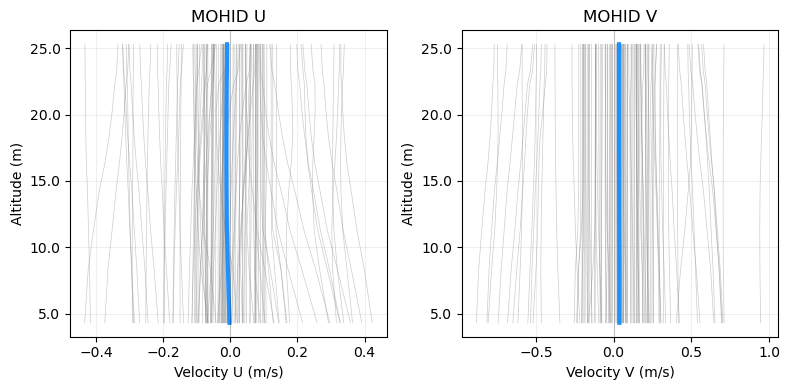

In [53]:
# converting to dataarray
vel_u = metrics.layers_to_dataarray(binned_full, column='velocity_U')
vel_v = metrics.layers_to_dataarray(binned_full, column='velocity_V')


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
custom.plot_profiles(vel_u,
                     range_coord='range',
                     range_slice=(0,25.3),        
                     xlabel='Velocity U (m/s)',
                     ylabel='Altitude (m)',
                     title='MOHID U',
                     mean_color='blue',
                     ax=axes[0])
custom.plot_profiles(vel_v,
                     range_coord='range',
                     range_slice=(0,25.3),        
                     xlabel='Velocity V (m/s)',
                     ylabel='Altitude (m)',
                     title='MOHID V',
                     mean_color='blue',
                     ax=axes[1])
plt.show()

In [73]:
# perhaps plot later
#vel_modulus = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_modulus')
#vel_dir = metrics.layers_to_dataarray(all_results['Run1'], column='velocity_direction')

### Calculating metrics

In [50]:
# define metrics to calculate
metric_fns = [metrics.rmse, metrics.bias, metrics.mss, metrics.pearson_r]

df_all_upper = metrics.compare_multi_metrics(
    run=model_output_upper, 
    reference=ADCP_upper, 
    metric_fns = metric_fns)

df_all_lower = metrics.compare_multi_metrics(
    run=model_output_lower, 
    reference=ADCP_lower, 
    metric_fns = metric_fns)

In [51]:
df_all_upper

,variable,rmse,bias,mss,pearson_r
0,velocity_U,0.166935,0.011204,0.235153,-0.011045
1,velocity_V,0.370394,-0.085710,0.357487,0.095538
2,velocity_modulus,0.268555,0.088139,0.279671,0.087326
3,velocity_direction,173.849042,2.616883,0.434454,-0.036975


In [52]:
df_all_lower

,variable,rmse,bias,mss,pearson_r
0,velocity_U,0.160427,0.009728,0.239045,-0.027173
1,velocity_V,0.353101,-0.087270,0.372401,0.101931
2,velocity_modulus,0.249183,0.075511,0.298106,0.088201
3,velocity_direction,167.087909,-4.344111,0.492374,0.066947
